# WER / CER Evaluation — Baseline vs Fine-tuned LoRA Adapters

Evaluates **100 samples per severity** from `cdli/ugandan_english_nonstandard_speech_v1.0` using:
- `openai/whisper-large-v3` (baseline, no fine-tuning)
- `jojo007unfi/whisper-mild` (LoRA adapter — mild)
- `jojo007unfi/whisper-moderate` (LoRA adapter — moderate)
- `jojo007unfi/whisper-severe` (LoRA adapter — severe)

Outputs a per-severity WER/CER comparison table and a grouped bar chart.

## Cell 1 — Install packages

In [9]:
import subprocess, sys

packages = [
    "huggingface_hub==0.23.4", "datasets==2.19.2", "peft==0.11.1",
    "accelerate>=0.30.0", "transformers>=4.39.0",
    "evaluate", "jiwer", "soundfile", "librosa",
    "numpy", "pandas", "matplotlib", "normalise",
]
for pkg in packages:
    r = subprocess.run([sys.executable, "-m", "pip", "install", "-q", pkg],
                      capture_output=True, text=True)
    print(f"  {'OK' if r.returncode == 0 else 'FAIL'} {pkg}")
print("Done.")

  OK huggingface_hub==0.23.4
  OK datasets==2.19.2
  OK peft==0.11.1
  OK accelerate>=0.30.0
  OK transformers>=4.39.0
  OK evaluate
  OK jiwer
  OK soundfile
  OK librosa
  OK numpy
  OK pandas
  OK matplotlib
  OK normalise
Done.


## Cell 2 — Imports

In [10]:
import os, re, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from tqdm.auto import tqdm

from datasets import load_dataset, Audio
from huggingface_hub import login, hf_hub_download
from transformers import WhisperForConditionalGeneration, WhisperProcessor
from peft import PeftModel
import evaluate

warnings.filterwarnings("ignore")

print(f"PyTorch  : {torch.__version__}")
print(f"CUDA     : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU      : {torch.cuda.get_device_name(0)}")
    print(f"VRAM     : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch  : 2.8.0+cu129
CUDA     : True
GPU      : NVIDIA A100-SXM4-40GB
VRAM     : 42.4 GB


## Cell 3 — Config

In [11]:
# ── Auth ──────────────────────────────────────────────────────────────────────
HF_TOKEN = os.environ.get("HF_TOKEN", "")

# ── Dataset ───────────────────────────────────────────────────────────────────
DATASET_NAME    = "cdli/ugandan_english_nonstandard_speech_v1.0"
AUDIO_COL       = "audio"
TRANSCRIPT_COL  = "transcription"
SPEAKER_COL     = "speaker_id"
SAMPLE_RATE     = 16_000
LANGUAGE        = "en"
TASK            = "transcribe"
SAMPLES_PER_SEVERITY = None  # None = use ALL available samples per severity

# ── Models ────────────────────────────────────────────────────────────────────
BASE_MODEL_ID = "openai/whisper-large-v3"

ADAPTER_REPOS = {
    "mild":     "jojo007unfi/whisper-mild-lora-adapter",
    "moderate": "jojo007unfi/whisper-moderate-lora-adapter",
    "severe":   "jojo007unfi/whisper-severe-lora-adapter",
}

SEVERITIES = ["mild", "moderate", "severe"]

# ── Generation kwargs (match serving script exactly) ─────────────────────────
# ── Generation kwargs — must match training exactly ───────────────────────────
# Training used: num_beams=5, no_repeat_ngram_size=3, repetition_penalty=1.3
# Using different kwargs here would invalidate the comparison.
GEN_KWARGS = dict(
    language             = LANGUAGE,
    task                 = TASK,
    num_beams            = 5,        # match training
    max_new_tokens       = 225,
    no_repeat_ngram_size = 3,        # match training
    repetition_penalty   = 1.3,      # match training
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device                : {device}")
print(f"Samples per severity  : {SAMPLES_PER_SEVERITY}")
print(f"Samples per severity  : {SAMPLES_PER_SEVERITY if SAMPLES_PER_SEVERITY else 'ALL'}")

Device                : cuda
Samples per severity  : None
Samples per severity  : ALL


## Cell 4 — HuggingFace login

In [12]:
if not HF_TOKEN:
    HF_TOKEN = input("Paste your HuggingFace token: ").strip()
os.environ["HF_TOKEN"] = HF_TOKEN
login(token=HF_TOKEN, add_to_git_credential=False)
print("Logged in.")

Note: Environment variable`HF_TOKEN` is set and is the current active token independently from the token you've just configured.


Logged in.


## Cell 5 — Load dataset & build per-severity sample pools

In [13]:
# ── Download parquet shards ───────────────────────────────────────────────────
PARQUET_FILES = {
    "test": [
        "data/test-00000-of-00002.parquet",
        "data/test-00001-of-00002.parquet",
    ],
}

print("Downloading test shards...")
local_files = {"test": []}
for fname in PARQUET_FILES["test"]:
    print(f"  {fname.split('/')[-1]} ...", end=" ", flush=True)
    path = hf_hub_download(
        repo_id=DATASET_NAME, filename=fname,
        repo_type="dataset", token=HF_TOKEN,
    )
    local_files["test"].append(path)
    print("OK")

raw = load_dataset("parquet", data_files=local_files)
test_ds = raw["test"].cast_column(AUDIO_COL, Audio(sampling_rate=SAMPLE_RATE))
print(f"Test set: {len(test_ds):,} samples")

# ── Load speaker → severity map ───────────────────────────────────────────────
print("\nLoading speaker metadata...")
meta_path = hf_hub_download(
    repo_id=DATASET_NAME, filename="speaker_metadata.csv",
    repo_type="dataset", token=HF_TOKEN,
)
speaker_meta = pd.read_csv(meta_path)
# Dataset severity labels are full descriptive strings, e.g.:
#   "mild (easily understood with minimal effort)"
# Map them to short keys by keyword substring matching.
def _to_short_severity(label: str) -> str:
    label = label.lower()
    for key in ["mild", "moderate", "severe", "profound"]:
        if key in label:
            return key
    return "unknown"

spk_to_severity = {
    str(row["speaker_id"]): _to_short_severity(str(row["severity_speech_impairment"]))
    for _, row in speaker_meta.iterrows()
}
print(f"Severity map: {len(spk_to_severity)} speakers")
print(f"Severity counts: {pd.Series(spk_to_severity.values()).value_counts().to_dict()}")

# ── Build per-severity sample pools (exactly SAMPLES_PER_SEVERITY each) ───────
print(f"\nBuilding sample pools (limit={SAMPLES_PER_SEVERITY if SAMPLES_PER_SEVERITY else 'ALL'} per severity)...")

# Shuffle indices so we get a representative spread across speakers,
# not just the first N rows (which may cluster around a single speaker).
import random as _random
all_indices = list(range(len(test_ds)))
_random.seed(42)
_random.shuffle(all_indices)

severity_samples = {sev: [] for sev in SEVERITIES}
for idx in all_indices:
    row     = test_ds[idx]
    speaker = str(row.get(SPEAKER_COL, ""))
    sev     = spk_to_severity.get(speaker, "unknown").lower()
    if sev in severity_samples:
        if SAMPLES_PER_SEVERITY is None or len(severity_samples[sev]) < SAMPLES_PER_SEVERITY:
            severity_samples[sev].append(row)

for sev, rows in severity_samples.items():
    n_speakers = len(set(str(r.get(SPEAKER_COL,"")) for r in rows))
    print(f"  {sev:10s}: {len(rows)} samples from {n_speakers} speakers")


  test-00000-of-00002.parquet ... OK
  test-00001-of-00002.parquet ... OK
Test set: 1,017 samples

Loading speaker metadata...
Severity map: 59 speakers
Severity counts: {'moderate': 23, 'severe': 23, 'mild': 11, 'profound': 2}

Building sample pools (limit=ALL per severity)...
  mild      : 337 samples from 3 speakers
  moderate  : 341 samples from 3 speakers
  severe    : 339 samples from 3 speakers


## Cell 5b — Diagnostic: sample pool breakdown

In [14]:
# ── Diagnostic: verify sample distribution before running inference ──────────
print("Sample pool breakdown:")
print(f"{'Severity':<12} {'Samples':>8} {'Speakers':>10} {'Samples/Speaker':>16}")
print("-" * 50)
for sev in SEVERITIES:
    rows = severity_samples[sev]
    if not rows:
        print(f"{sev:<12} {'0':>8} {'0':>10} {'n/a':>16}")
        continue
    speakers = [str(r.get(SPEAKER_COL, "")) for r in rows]
    n_speakers = len(set(speakers))
    from collections import Counter
    spk_counts = Counter(speakers)
    print(f"{sev:<12} {len(rows):>8} {n_speakers:>10} {len(rows)/n_speakers:>15.1f}x")
    print(f"  Speaker sample counts: {dict(spk_counts)}")

print()
# Sanity-check: print one reference transcript per severity
for sev in SEVERITIES:
    rows = severity_samples[sev]
    if rows:
        sample = rows[0]
        ref = normalise(str(sample[TRANSCRIPT_COL]))
        print(f"  [{sev}] sample ref: '{ref[:80]}'")


Sample pool breakdown:
Severity      Samples   Speakers  Samples/Speaker
--------------------------------------------------
mild              337          3           112.3x
  Speaker sample counts: {'UG022': 102, 'UG014': 133, 'UG001': 102}
moderate          341          3           113.7x
  Speaker sample counts: {'UG021': 77, 'UG036': 151, 'UG052': 113}
severe            339          3           113.0x
  Speaker sample counts: {'UG057': 96, 'UG058': 151, 'UG042': 92}

  [mild] sample ref: 'wake up early this morning to prepare tea but the power went off sadly and i had'
  [moderate] sample ref: 'most parts of uganda we have people who have different cultures like the karamaj'
  [severe] sample ref: 'the boda promised to come but he lied'


## Cell 6 — Helpers (normalise, transcribe, evaluate)

In [15]:
wer_metric = evaluate.load("wer")
cer_metric = evaluate.load("cer")

def normalise(text: str) -> str:
    """Lowercase, strip punctuation, collapse whitespace — identical to training."""
    text = text.lower().strip()
    text = re.sub(r"[^\w\s']", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def run_inference(model, processor, samples: list, desc: str) -> tuple[list, list]:
    """Run Whisper inference on a list of dataset rows. Returns (refs, hyps)."""
    refs, hyps = [], []
    model.eval()
    for row in tqdm(samples, desc=desc, leave=False):
        audio = row[AUDIO_COL]
        ref   = normalise(str(row[TRANSCRIPT_COL]))

        inputs = processor(
            audio["array"],
            sampling_rate=audio["sampling_rate"],
            return_tensors="pt",
            return_attention_mask=True,
        )
        input_features = inputs.input_features.to(device, dtype=torch.float16)
        attention_mask = inputs.attention_mask.to(device)

        with torch.no_grad():
            ids = model.generate(
                input_features,
                attention_mask=attention_mask,
                **GEN_KWARGS,
            )
        hyp = normalise(processor.tokenizer.decode(ids[0], skip_special_tokens=True))

        refs.append(ref)
        hyps.append(hyp)

    return refs, hyps

def compute_metrics(refs: list, hyps: list) -> dict:
    """Compute WER and CER with safe handling of empty inputs."""
    # If no references, return zeros
    if not refs or len(refs) == 0:
        return {"wer": 0.0, "cer": 0.0}
    
    try:
        wer = round(100 * wer_metric.compute(predictions=hyps, references=refs), 2)
        cer = round(100 * cer_metric.compute(predictions=hyps, references=refs), 2)
        return {"wer": wer, "cer": cer}
    except ZeroDivisionError:
        return {"wer": 0.0, "cer": 0.0}

print("Helpers ready.")

Helpers ready.


## Cell 7 — Evaluate baseline: `whisper-large-v3` (no fine-tuning)

In [16]:
print(f"Loading baseline: {BASE_MODEL_ID} ...")
base_processor = WhisperProcessor.from_pretrained(
    BASE_MODEL_ID, language=LANGUAGE, task=TASK, token=HF_TOKEN
)
baseline_model = WhisperForConditionalGeneration.from_pretrained(
    BASE_MODEL_ID, dtype=torch.float16, device_map="auto", token=HF_TOKEN
)
baseline_model.config.forced_decoder_ids            = None
baseline_model.config.suppress_tokens               = []
baseline_model.generation_config.forced_decoder_ids = None
print("Baseline model loaded.\n")

baseline_results = {}  # severity -> {wer, cer}

for sev in SEVERITIES:
    samples = severity_samples[sev]
    
    # Skip empty severity categories
    if len(samples) == 0:
        print(f"  Baseline  {sev:10s}  (0 samples - skipping)")
        baseline_results[sev] = {"wer": 0.0, "cer": 0.0, "n_samples": 0}
        continue
    
    refs, hyps = run_inference(
        baseline_model, base_processor, samples,
        desc=f"Baseline / {sev} ({len(samples)} samples)"
    )
    metrics = compute_metrics(refs, hyps)
    baseline_results[sev] = metrics
    print(f"  Baseline  {sev:10s}  WER={metrics['wer']:.1f}%   CER={metrics['cer']:.1f}%")

print("\nBaseline evaluation complete.")

# Free VRAM before loading adapters
del baseline_model
torch.cuda.empty_cache()

Loading baseline: openai/whisper-large-v3 ...


Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Baseline model loaded.



Baseline / mild (337 samples):   0%|          | 0/337 [00:00<?, ?it/s]

  Baseline  mild        WER=25.4%   CER=14.9%


Baseline / moderate (341 samples):   0%|          | 0/341 [00:00<?, ?it/s]

  Baseline  moderate    WER=27.6%   CER=17.6%


Baseline / severe (339 samples):   0%|          | 0/339 [00:00<?, ?it/s]

  Baseline  severe      WER=30.4%   CER=21.1%

Baseline evaluation complete.


## Cell 8 — Evaluate each LoRA adapter on its matching severity

Each adapter is loaded, merged, run on **all three severities**, then unloaded to keep VRAM manageable.

In [17]:
# adapter_results[adapter_severity][eval_severity] = {wer, cer}
adapter_results = {sev: {} for sev in SEVERITIES}

for adapter_sev in SEVERITIES:
    repo = ADAPTER_REPOS[adapter_sev]
    print(f"\n{'='*60}")
    print(f"Loading adapter: {repo}")
    print(f"{'='*60}")

    # Load base + merge LoRA
    base = WhisperForConditionalGeneration.from_pretrained(
        BASE_MODEL_ID, dtype=torch.float16,
        device_map="auto", token=HF_TOKEN
    )
    peft_model = PeftModel.from_pretrained(base, repo, token=HF_TOKEN)
    model      = peft_model.merge_and_unload()
    model.config.forced_decoder_ids            = None
    model.config.suppress_tokens               = []
    model.generation_config.forced_decoder_ids = None
    processor  = WhisperProcessor.from_pretrained(
        BASE_MODEL_ID, language=LANGUAGE, task=TASK, token=HF_TOKEN
    )
    print(f"Adapter merged and ready.")

    for eval_sev in SEVERITIES:
        samples = severity_samples[eval_sev]
        refs, hyps = run_inference(
            model, processor, samples,
            desc=f"  Adapter={adapter_sev} / Eval={eval_sev} ({len(samples)} samples)"
        )
        metrics = compute_metrics(refs, hyps)
        adapter_results[adapter_sev][eval_sev] = metrics
        print(f"  [{adapter_sev} adapter] eval on {eval_sev:10s}  "
              f"WER={metrics['wer']:.1f}%   CER={metrics['cer']:.1f}%")

    del model, peft_model, base
    torch.cuda.empty_cache()
    print(f"  ({adapter_sev} adapter unloaded)")

print("\nAll adapter evaluations complete.")


Loading adapter: jojo007unfi/whisper-mild-lora-adapter


adapter_config.json:   0%|          | 0.00/822 [00:00<?, ?B/s]

adapter_model.safetensors:   0%|          | 0.00/115M [00:00<?, ?B/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

Adapter merged and ready.


...

  [severe adapter] eval on mild        WER=20.7%   CER=11.8%


  Adapter=severe / Eval=moderate (341 samples):   0%|          | 0/341 [00:00<?, ?it/s]

  [severe adapter] eval on moderate    WER=20.9%   CER=12.4%


  Adapter=severe / Eval=severe (339 samples):   0%|          | 0/339 [00:00<?, ?it/s]

  [severe adapter] eval on severe      WER=25.4%   CER=17.8%
  (severe adapter unloaded)

All adapter evaluations complete.


## Cell 9 — Build results table

In [18]:
# ── Primary table: each adapter evaluated on its MATCHING severity ─────────────
# This is the fair comparison: mild adapter vs baseline on mild samples, etc.
rows = []
for sev in SEVERITIES:
    b = baseline_results[sev]
    f = adapter_results[sev][sev]  # matched severity
    rows.append({
        "Severity":            sev.capitalize(),
        "Baseline WER (%)": b["wer"],
        "Baseline CER (%)": b["cer"],
        "LoRA WER (%)": f["wer"],
        "LoRA CER (%)": f["cer"],
        "WER Δ (pp)": round(f["wer"] - b["wer"], 2),
        "CER Δ (pp)": round(f["cer"] - b["cer"], 2),
        "WER Rel. Improv. (%)": round(100 * (b["wer"] - f["wer"]) / b["wer"], 1) if b["wer"] > 0 else 0,
        "CER Rel. Improv. (%)": round(100 * (b["cer"] - f["cer"]) / b["cer"], 1) if b["cer"] > 0 else 0,
    })

main_table = pd.DataFrame(rows)

print("\n" + "="*70)
print("PRIMARY COMPARISON — each adapter evaluated on its matched severity")
print("="*70)
print(main_table.to_string(index=False))

# ── Cross-severity table: all adapters on all severities ──────────────────────
cross_rows = []
for eval_sev in SEVERITIES:
    row = {"Eval Severity": eval_sev.capitalize()}
    b = baseline_results[eval_sev]
    row["Baseline WER"] = f"{b['wer']:.1f}%"
    row["Baseline CER"] = f"{b['cer']:.1f}%"
    for adapter_sev in SEVERITIES:
        m = adapter_results[adapter_sev][eval_sev]
        row[f"{adapter_sev.capitalize()} Adapter WER"] = f"{m['wer']:.1f}%"
        row[f"{adapter_sev.capitalize()} Adapter CER"] = f"{m['cer']:.1f}%"
    cross_rows.append(row)

cross_table = pd.DataFrame(cross_rows)

print("\n" + "="*70)
print("CROSS-SEVERITY TABLE — all adapters on all evaluation severities")
print("="*70)
print(cross_table.to_string(index=False))


PRIMARY COMPARISON — each adapter evaluated on its matched severity
Severity  Baseline WER (%)  Baseline CER (%)  LoRA WER (%)  LoRA CER (%)  WER Δ (pp)  CER Δ (pp)  WER Rel. Improv. (%)  CER Rel. Improv. (%)
    Mild             25.45             14.92         21.91         12.31       -3.54       -2.61                  13.9                  17.5
Moderate             27.55             17.62         20.90         12.15       -6.65       -5.47                  24.1                  31.0
  Severe             30.43             21.08         25.35         17.77       -5.08       -3.31                  16.7                  15.7

CROSS-SEVERITY TABLE — all adapters on all evaluation severities
Eval Severity Baseline WER Baseline CER Mild Adapter WER Mild Adapter CER Moderate Adapter WER Moderate Adapter CER Severe Adapter WER Severe Adapter CER
         Mild        25.4%        14.9%            21.9%            12.3%                21.6%                11.8%              20.7%             

## Cell 10 — Visualise results

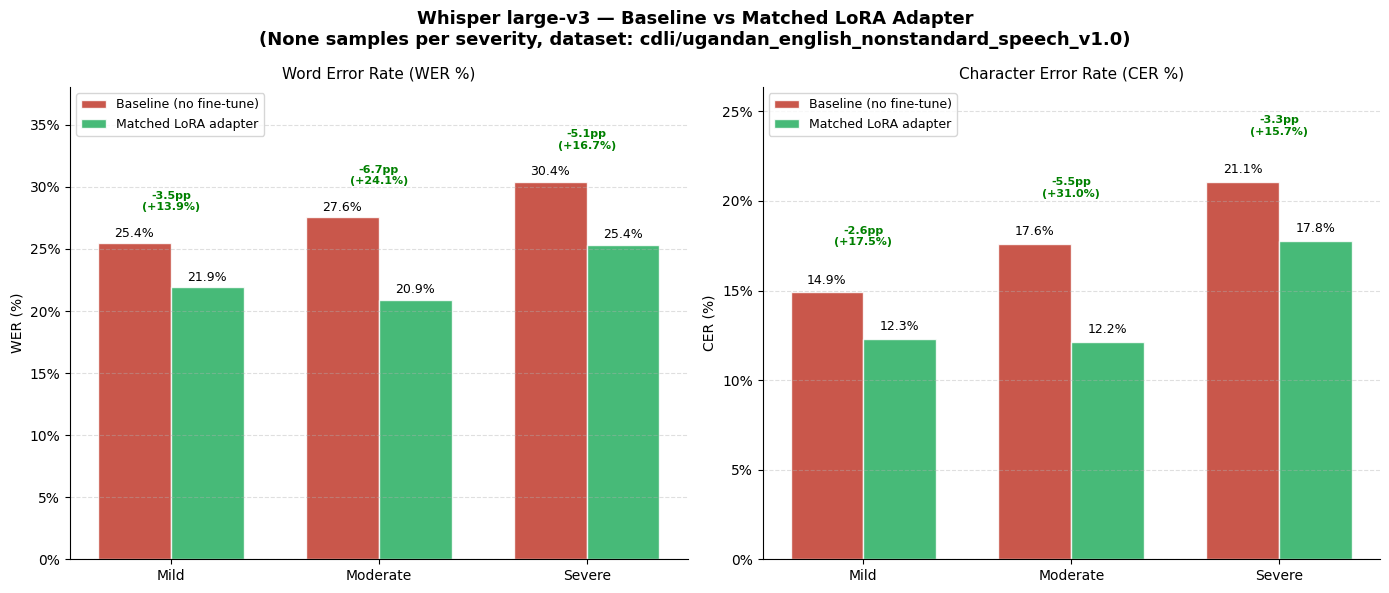

Chart saved to wer_cer_comparison.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    f"Whisper large-v3 — Baseline vs Matched LoRA Adapter\n"
    f"({SAMPLES_PER_SEVERITY} samples per severity, dataset: {DATASET_NAME})",
    fontsize=13, fontweight="bold",
)

severity_labels = [r["Severity"] for r in rows]
x = np.arange(len(severity_labels))
width = 0.35
COLOR_BASELINE = "#c0392b"
COLOR_LORA     = "#27ae60"

for ax, metric, title in [
    (axes[0], "WER", "Word Error Rate (WER %)"),
    (axes[1], "CER", "Character Error Rate (CER %)"),
]:
    base_vals = [r[f"Baseline {metric} (%)"] for r in rows]
    lora_vals = [r[f"LoRA {metric} (%)"]     for r in rows]

    bars_base = ax.bar(x - width/2, base_vals, width, label="Baseline (no fine-tune)",
                       color=COLOR_BASELINE, alpha=0.85, edgecolor="white")
    bars_lora = ax.bar(x + width/2, lora_vals, width, label="Matched LoRA adapter",
                       color=COLOR_LORA,     alpha=0.85, edgecolor="white")

    # Value labels
    for bar in bars_base:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)
    for bar in bars_lora:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                f"{bar.get_height():.1f}%", ha="center", va="bottom", fontsize=9)

    # Improvement annotations
    for i, r in enumerate(rows):
        delta = r[f"{metric} Δ (pp)"]
        rel   = r[f"{metric} Rel. Improv. (%)"]
        sign  = "+" if delta > 0 else ""
        color = "green" if delta < 0 else "red"
        ax.text(i, max(base_vals[i], lora_vals[i]) + 2.5,
                f"{sign}{delta:.1f}pp\n({rel:+.1f}%)",
                ha="center", va="bottom", fontsize=8, color=color, fontweight="bold")

    ax.set_title(title, fontsize=11)
    ax.set_xticks(x)
    ax.set_xticklabels(severity_labels, fontsize=10)
    ax.set_ylabel(f"{metric} (%)", fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.0f%%"))
    ax.legend(fontsize=9)
    ax.set_ylim(0, max(max(base_vals), max(lora_vals)) * 1.25)
    ax.spines[["top", "right"]].set_visible(False)
    ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("wer_cer_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("Chart saved to wer_cer_comparison.png")

## Cell 11 — Per-sample detail table (optional inspection)

In [20]:
# Re-run inference with per-sample logging for the matched pairs only.
# Useful for qualitative inspection — paste a few bad examples into the READMEs.
# NOTE: this re-runs inference; skip if you just need aggregate numbers.

print("Re-running matched pairs for per-sample inspection...\n")
detail_rows = []

for sev in SEVERITIES:
    adapter_repo = ADAPTER_REPOS[sev]

    # Load adapter
    base  = WhisperForConditionalGeneration.from_pretrained(
        BASE_MODEL_ID, dtype=torch.float16, device_map="auto", token=HF_TOKEN
    )
    peft_model = PeftModel.from_pretrained(base, adapter_repo, token=HF_TOKEN)
    ft_model   = peft_model.merge_and_unload()
    ft_model.config.forced_decoder_ids            = None
    ft_model.config.suppress_tokens               = []
    ft_model.generation_config.forced_decoder_ids = None
    processor = WhisperProcessor.from_pretrained(
        BASE_MODEL_ID, language=LANGUAGE, task=TASK, token=HF_TOKEN
    )

    # Reload baseline too (for side-by-side)
    bl_model = WhisperForConditionalGeneration.from_pretrained(
        BASE_MODEL_ID, dtype=torch.float16, device_map="auto", token=HF_TOKEN
    )
    bl_model.config.forced_decoder_ids            = None
    bl_model.config.suppress_tokens               = []
    bl_model.generation_config.forced_decoder_ids = None

    for i, row in enumerate(tqdm(severity_samples[sev], desc=f"{sev} per-sample", leave=False)):
        audio = row[AUDIO_COL]
        ref   = normalise(str(row[TRANSCRIPT_COL]))

        def _infer(mdl):
            inp = processor(
                audio["array"], sampling_rate=audio["sampling_rate"],
                return_tensors="pt", return_attention_mask=True,
            )
            feats = inp.input_features.to(device, dtype=torch.float16)
            mask  = inp.attention_mask.to(device)
            with torch.no_grad():
                ids = mdl.generate(feats, attention_mask=mask, **GEN_KWARGS)
            return normalise(processor.tokenizer.decode(ids[0], skip_special_tokens=True))

        hyp_base = _infer(bl_model)
        hyp_ft   = _infer(ft_model)

        detail_rows.append({
            "severity": sev,
            "sample_idx": i,
            "reference": ref,
            "baseline_hyp": hyp_base,
            "lora_hyp": hyp_ft,
        })

    del ft_model, peft_model, bl_model, base
    torch.cuda.empty_cache()

detail_df = pd.DataFrame(detail_rows)
detail_df.to_csv("per_sample_results.csv", index=False)
print(f"Per-sample results saved to per_sample_results.csv  ({len(detail_df)} rows)")
detail_df.head(10)

Re-running matched pairs for per-sample inspection...



Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

mild per-sample:   0%|          | 0/337 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

moderate per-sample:   0%|          | 0/341 [00:00<?, ?it/s]

Fetching 1 files:   0%|          | 0/1 [00:00<?, ?it/s]

severe per-sample:   0%|          | 0/339 [00:00<?, ?it/s]

Per-sample results saved to per_sample_results.csv  (1017 rows)


,severity,sample_idx,reference,baseline_hyp,lora_hyp
0,mild,0,wake up early this morning to prepare tea but ...,wake up early this morning to prepare tea but ...,wake up early this morning to prepare tea but ...
1,mild,1,during christmas season many people travel to ...,during christmas season many people travel to ...,d during christmas season many people travel t...
2,mild,2,last time last time i visited my home i found ...,last time i visited my home i found that the b...,last time i visited my home i found that the b...
3,mild,3,in market places they sell a lot of things lik...,i mean marketplaces they sell a lot of things ...,market places they sell alot of things which i...
4,mild,4,what kind of food is that can you imagine yest...,what kind of food is that can you imagine yest...,what kind of food is that can you imagine yest...
5,mild,5,when the rain started we all ran for shelter b...,when the rain started we all ran for shelter b...,when the rain started we all ran for shelter b...
6,mild,6,a boy and a woman buying vegetable most men do...,a boy and a woman buying vegetables most men d...,a boy and a woman buying vegetable most men do...
7,mild,7,we always fetch water from that borehole but the,we always fetch water from that power hole but...,we always fetch water from that power hole but...
8,mild,8,the rain begins the whole road floods,when the rain begins the whole road floods and...,when the rain begins the whole road floods and...
9,mild,9,last night i had drums from a wedding ceremony...,last night i had drums roma wedding ceremony c...,last night i had drums from a wedding ceremony...


## Cell 12 — Export summary JSON (paste numbers into README placeholders)

In [21]:
import json

summary = {
    "dataset": DATASET_NAME,
    "samples_per_severity": SAMPLES_PER_SEVERITY,
    "base_model": BASE_MODEL_ID,
    "results": {}
}

for sev in SEVERITIES:
    b = baseline_results[sev]
    f = adapter_results[sev][sev]
    summary["results"][sev] = {
        "baseline_wer": b["wer"],
        "baseline_cer": b["cer"],
        "finetuned_wer": f["wer"],
        "finetuned_cer": f["cer"],
        "wer_delta_pp": round(f["wer"] - b["wer"], 2),
        "cer_delta_pp": round(f["cer"] - b["cer"], 2),
        "wer_relative_improvement_pct": round(100 * (b["wer"] - f["wer"]) / b["wer"], 1) if b["wer"] > 0 else None,
        "cer_relative_improvement_pct": round(100 * (b["cer"] - f["cer"]) / b["cer"], 1) if b["cer"] > 0 else None,
    }

with open("eval_summary.json", "w") as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print("\nSaved to eval_summary.json")
print("\nPaste these into your README placeholders:")
for sev, r in summary["results"].items():
    print(f"\n  [{sev.upper()} ADAPTER]")
    print(f"    [BASELINE_WER]          = {r['baseline_wer']}")
    print(f"    [BASELINE_CER]          = {r['baseline_cer']}")
    print(f"    [FINETUNED_WER]         = {r['finetuned_wer']}")
    print(f"    [FINETUNED_CER]         = {r['finetuned_cer']}")
    print(f"    [WER_REL_IMPROVEMENT]   = {r['wer_relative_improvement_pct']}")
    print(f"    [CER_REL_IMPROVEMENT]   = {r['cer_relative_improvement_pct']}")

{
  "dataset": "cdli/ugandan_english_nonstandard_speech_v1.0",
  "samples_per_severity": null,
  "base_model": "openai/whisper-large-v3",
  "results": {
    "mild": {
      "baseline_wer": 25.45,
      "baseline_cer": 14.92,
      "finetuned_wer": 21.91,
      "finetuned_cer": 12.31,
      "wer_delta_pp": -3.54,
      "cer_delta_pp": -2.61,
      "wer_relative_improvement_pct": 13.9,
      "cer_relative_improvement_pct": 17.5
    },
    "moderate": {
      "baseline_wer": 27.55,
      "baseline_cer": 17.62,
      "finetuned_wer": 20.9,
      "finetuned_cer": 12.15,
      "wer_delta_pp": -6.65,
      "cer_delta_pp": -5.47,
      "wer_relative_improvement_pct": 24.1,
      "cer_relative_improvement_pct": 31.0
    },
    "severe": {
      "baseline_wer": 30.43,
      "baseline_cer": 21.08,
      "finetuned_wer": 25.35,
      "finetuned_cer": 17.77,
      "wer_delta_pp": -5.08,
      "cer_delta_pp": -3.31,
      "wer_relative_improvement_pct": 16.7,
      "cer_relative_improvement_pct": 15